# Bank Marketing Subscription Prediction
End-to-end classification project focused on realistic CRM deployment and data leakage prevention.

This notebook covers **EDA and model evaluation only**.
Training logic lives in `src/` — imported here to keep concerns separated.

## Imports

In [40]:
import sys
# Make src/ importable from notebooks/
# The project root is /content/bank-marketing-mlops
sys.path.append('/content/bank-marketing-mlops')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.metrics import confusion_matrix, roc_auc_score

from src.train import load_data, split_features, make_splits, train, save_model

import warnings
warnings.filterwarnings('ignore')

## Load Data

In [41]:
df = load_data('data/bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,1
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,1
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,1
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,1
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,1


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 1.4+ MB


In [43]:
print(f'Shape: {df.shape}')
print(f'Missing values:\n{df.isnull().sum()}')

Shape: (11162, 17)
Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


The dataset contains 11,162 observations and 17 features. No missing values detected.

## Exploratory Data Analysis
### Target Distribution
Understanding class imbalance before modelling.

deposit
0    52.6
1    47.4
Name: proportion, dtype: float64


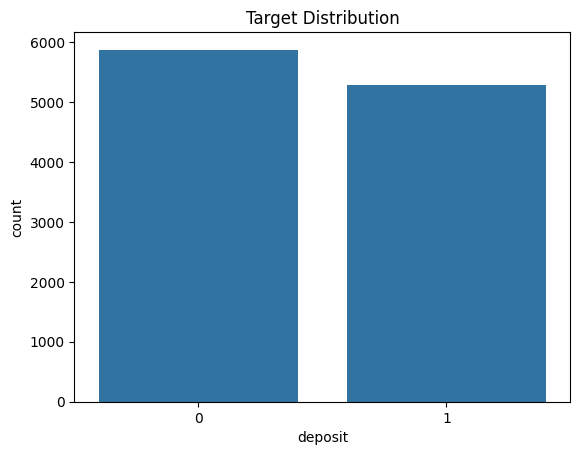

In [44]:
print(df['deposit'].value_counts(normalize=True).round(3) * 100)

sns.countplot(x='deposit', data=df)
plt.title('Target Distribution')
plt.show()

Moderate class imbalance: more non-subscribers than subscribers.  
Accuracy alone is insufficient — ROC-AUC, precision, recall are primary metrics.

### Numerical Features
Distribution and outlier analysis.

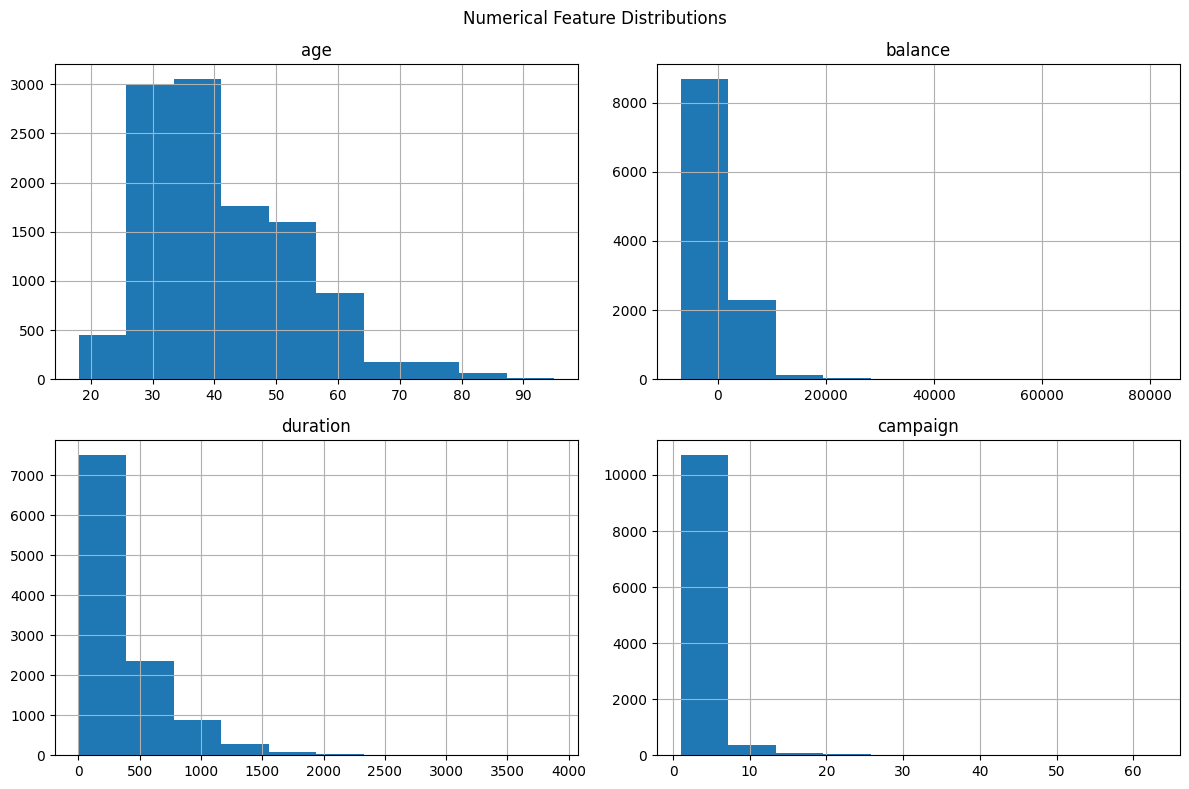

In [45]:
df[['age', 'balance', 'duration', 'campaign']].hist(figsize=(12, 8))
plt.suptitle('Numerical Feature Distributions')
plt.tight_layout()
plt.show()

- **Age**: well-distributed, 30–50 range dominant.
- **Balance**: highly right-skewed → log1p transformation applied in pipeline.
- **Duration**: strong skew → data leakage risk (see below).
- **Campaign**: concentrated at low values.

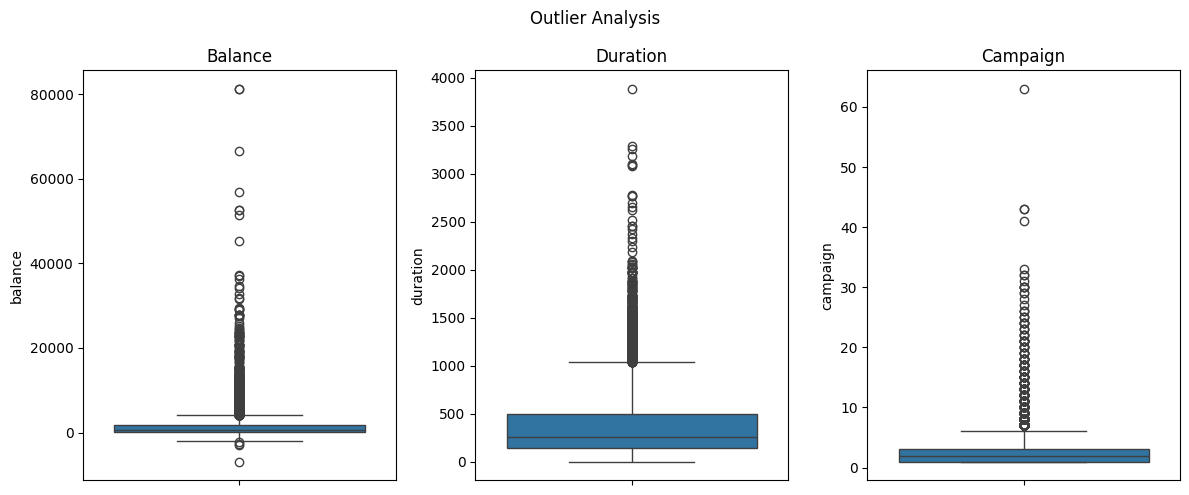

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for ax, col in zip(axes, ['balance', 'duration', 'campaign']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col.capitalize())
plt.suptitle('Outlier Analysis')
plt.tight_layout()
plt.show()

Outliers present in balance, duration and campaign.  
Not removed — tree-based models are robust to skewness and outliers.

### Categorical Features vs Target

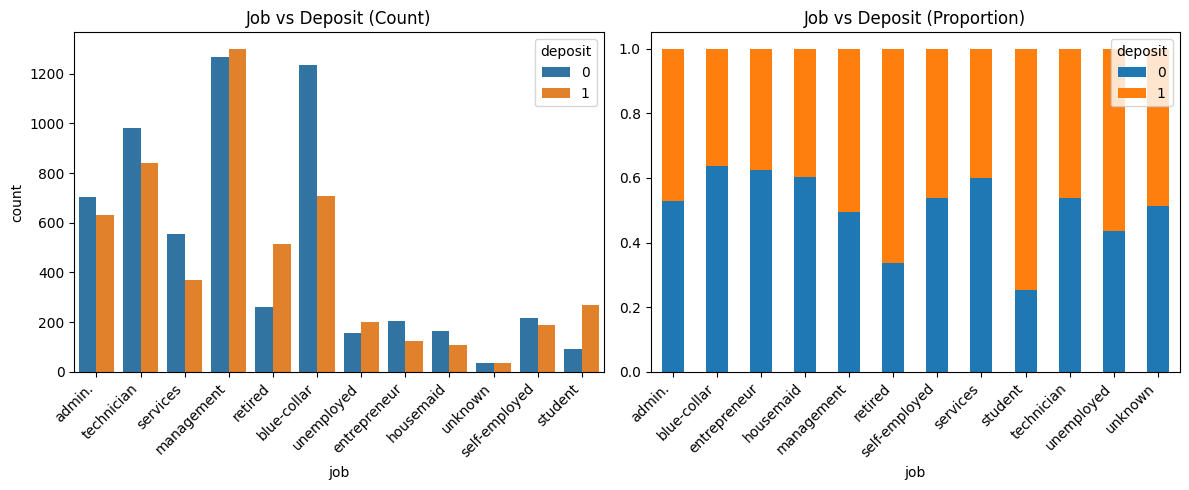

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='job', hue='deposit', data=df, ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_title('Job vs Deposit (Count)')

pd.crosstab(df['job'], df['deposit'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1]
)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_title('Job vs Deposit (Proportion)')

plt.tight_layout()
plt.show()

Students and retired customers show higher subscription rates. Blue-collar and services workers show lower engagement.
Occupation is a strong predictive feature.

### Data Leakage: `duration`

`duration` = length of the last call. Available **only after** the call ends — not at prediction time.

Strategy:
- **With duration**: benchmark only (not deployable).
- **Without duration**: realistic deployment scenario.

## Training
### Scenario 1 — With Duration (benchmark)

In [48]:
X_wd, y_wd = split_features(df, 'with_duration')
X_train_wd, X_val_wd, X_test_wd, y_train_wd, y_val_wd, y_test_wd = make_splits(X_wd, y_wd)

pipeline_wd, threshold_wd, model_name_wd, metrics_wd, _ = train(
    X_train_wd, X_val_wd, X_test_wd,
    y_train_wd, y_val_wd, y_test_wd,
    'with_duration')

Running GridSearchCV [with_duration]...
Val ROC-AUC  LR=0.906  RF=0.923
Best RF params: {'model__class_weight': None, 'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Selected: RandomForest
CV ROC-AUC: 0.917 ± 0.006
Default threshold (0.5) satisfies recall constraint.
Threshold: 0.500

--- Test Performance ---
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1175
           1       0.83      0.88      0.85      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233

ROC-AUC: 0.918


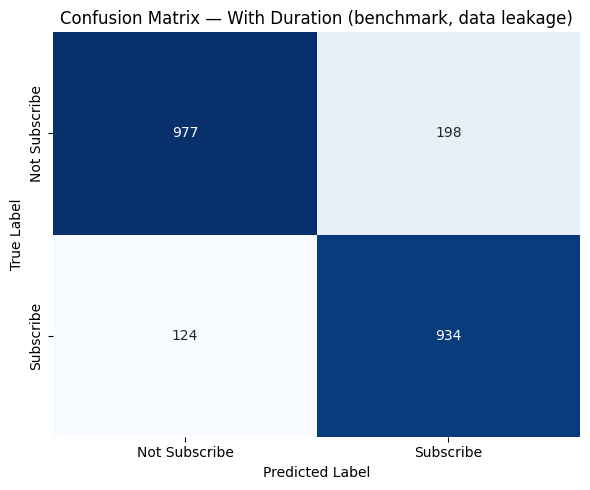

In [49]:
y_proba_wd = pipeline_wd.predict_proba(X_test_wd)[:, 1]
y_pred_wd = (y_proba_wd >= threshold_wd).astype(int)

cm = confusion_matrix(y_test_wd, y_pred_wd)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Subscribe', 'Subscribe'],
            yticklabels=['Not Subscribe', 'Subscribe'])
plt.title('Confusion Matrix — With Duration (benchmark, data leakage)')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### Scenario 2 — Without Duration (realistic deployment)

In [50]:
X_nd, y_nd = split_features(df, 'without_duration')
X_train_nd, X_val_nd, X_test_nd, y_train_nd, y_val_nd, y_test_nd = make_splits(X_nd, y_nd)

pipeline_nd, threshold_nd, model_name_nd, metrics_nd, _ = train(
    X_train_nd, X_val_nd, X_test_nd,
    y_train_nd, y_val_nd, y_test_nd,
    'without_duration')

Running GridSearchCV [without_duration]...
Val ROC-AUC  LR=0.772  RF=0.785
Best RF params: {'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Selected: RandomForest
CV ROC-AUC: 0.786 ± 0.011
Threshold: 0.414

--- Test Performance ---
              precision    recall  f1-score   support

           0       0.73      0.70      0.72      1175
           1       0.68      0.72      0.70      1058

    accuracy                           0.71      2233
   macro avg       0.71      0.71      0.71      2233
weighted avg       0.71      0.71      0.71      2233

ROC-AUC: 0.773


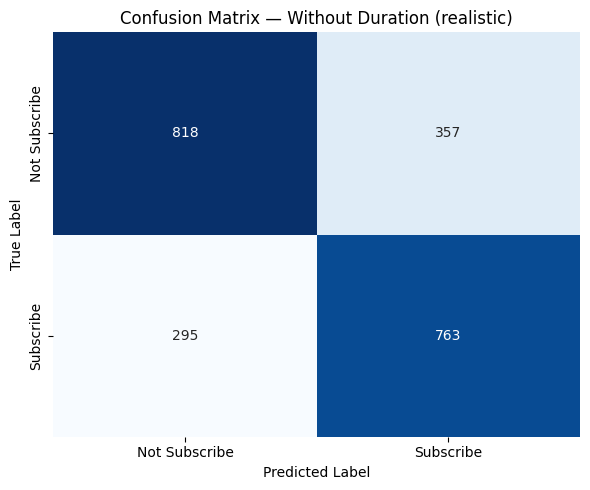

In [51]:
y_proba_nd = pipeline_nd.predict_proba(X_test_nd)[:, 1]
y_pred_nd = (y_proba_nd >= threshold_nd).astype(int)

cm = confusion_matrix(y_test_nd, y_pred_nd)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Subscribe', 'Subscribe'],
            yticklabels=['Not Subscribe', 'Subscribe'])
plt.title('Confusion Matrix — Without Duration (realistic)')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### Scenario Comparison

In [52]:
comparison = pd.DataFrame({
    'Metric': ['Val ROC-AUC RF', 'CV ROC-AUC (mean)', 'Test ROC-AUC', 'Threshold'],
    'With Duration': [
        round(metrics_wd['val_roc_auc_rf'], 3),
        round(metrics_wd['cv_roc_auc_mean'], 3),
        round(metrics_wd['test_roc_auc'], 3),
        round(metrics_wd['threshold'], 3)
        ],
    'Without Duration': [
        round(metrics_nd['val_roc_auc_rf'], 3),
        round(metrics_nd['cv_roc_auc_mean'], 3),
        round(metrics_nd['test_roc_auc'], 3),
        round(metrics_nd['threshold'], 3)
        ]
    })
comparison.set_index('Metric')

,With Duration,Without Duration
Metric,,
Val ROC-AUC RF,0.923,0.785
CV ROC-AUC (mean),0.917,0.786
Test ROC-AUC,0.918,0.773
Threshold,0.500,0.414


Performance drop without `duration` is expected and confirms the leakage hypothesis.  
The realistic model (without duration) is the only one valid for deployment.

## Feature Importance — SHAP
Applied to realistic model (without duration).

In [53]:
model = pipeline_nd.named_steps['model']
preprocessor = pipeline_nd.named_steps['preprocessor']

X_test_transformed = preprocessor.transform(X_test_nd)
feature_names = preprocessor.named_steps['column'].get_feature_names_out()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)
shap_values_pos = shap_values[:, :, 1]

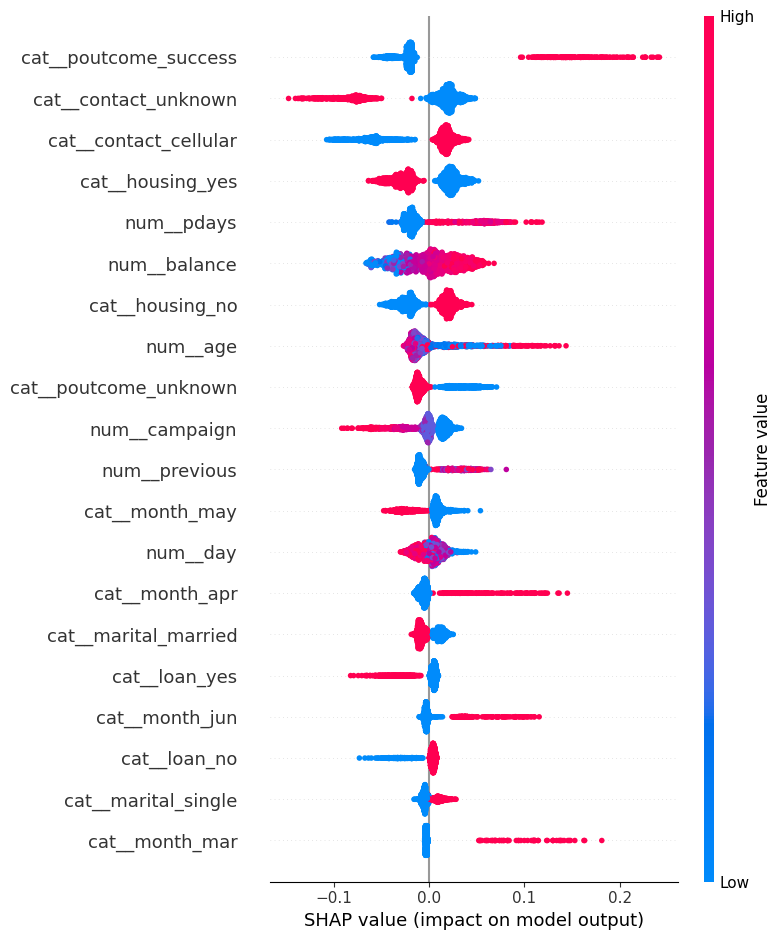

In [54]:
shap.summary_plot(shap_values_pos, X_test_transformed, feature_names=feature_names)

Each point = one prediction. X-axis = SHAP value (impact on output). Color = feature value magnitude.

Positive SHAP → increases probability of subscription. Negative → decreases.

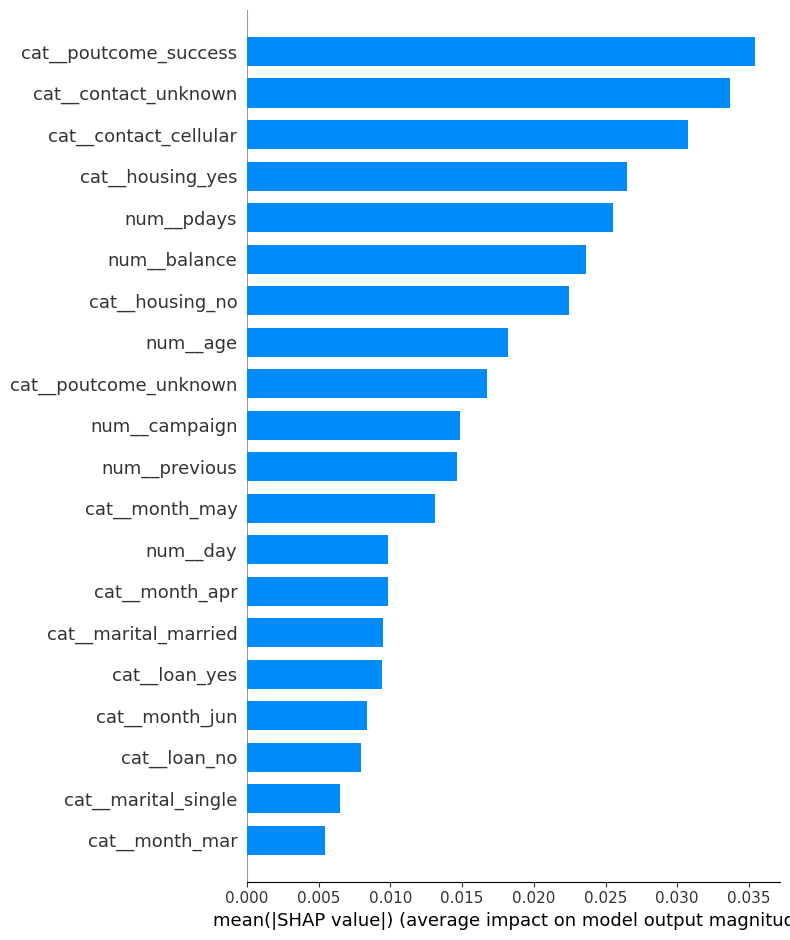

In [55]:
shap.summary_plot(shap_values_pos, X_test_transformed, feature_names=feature_names, plot_type='bar')

In [56]:
shap_importance = np.abs(shap_values_pos).mean(axis=0)
shap_df = pd.DataFrame({'feature': feature_names, 'shap_importance': shap_importance})
shap_df.sort_values('shap_importance', ascending=False).head(10)

,feature,shap_importance
48,cat__poutcome_success,0.035400
33,cat__contact_unknown,0.033703
31,cat__contact_cellular,0.030722
28,cat__housing_yes,0.026503
4,num__pdays,0.025545
1,num__balance,0.023641
27,cat__housing_no,0.022443
0,num__age,0.018211
49,cat__poutcome_unknown,0.016750
3,num__campaign,0.014846


**Top drivers:**
1. `poutcome_success` — previous campaign success strongly predicts subscription.
2. `contact_unknown` / `contact_cellular` — communication channel matters.
3. `housing_yes` — financial situation signal.
4. `pdays` — recency of previous contact.
5. `balance` — account balance.

Model relies on **behavioral and historical** features, not purely demographic.

## Conclusions

- **Best model**: Random Forest (tuned via GridSearchCV), selected in both scenarios.
- **Realistic ROC-AUC**: 0.773 without duration — acceptable for deployment.
- **Threshold**: tuned on validation set to enforce recall ≥ 0.75 for class 1.
- **SHAP**: previous campaign outcome and contact channel are dominant predictors.

**MLOps pipeline**: training logic in `src/train.py`, served via FastAPI (`api/`), tracked with MLflow.